### 🔁 What is Iterative Retrieval in Agentic RAG?
Combined both Iterative And Self reflection

✅ Definition:
Iterative Retrieval is a dynamic strategy where an AI agent doesn't settle for the first batch of retrieved documents. Instead, it evaluates the adequacy of the initial context, and if necessary, it:

- Refines the query,
- Retrieves again,
- Repeats the process until it’s confident enough to answer the original question.

🧠 Why Use It?
In standard RAG:

- A single retrieval step is done, and the LLM uses it to answer.
- If the documents were incomplete or irrelevant, the answer may fail.

In Iterative RAG:

- The agent reflects on the retrieved content and the answer it produced.
- If it’s unsure, it can refine its search (like a human researcher would).

In [16]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Literal
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from IPython.display import display, Markdown
import warnings

In [17]:
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [18]:
load_dotenv()

True

In [19]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [20]:
llm=init_chat_model("openai:gpt-4o")

In [21]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader('internal_docs.txt', encoding='utf-8').load()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 200
)
chunks = text_splitter.split_documents(docs)
vector_store = FAISS.from_documents(chunks, OpenAIEmbeddings())
retriever = vector_store.as_retriever()

In [22]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class IterativeRAGState(TypedDict):
    question: str
    refined_question: str
    retrieved_docs: List[Document]
    answer: str
    verified: bool
    attempts: int
    max_attempt: int

In [23]:
class ReflectionSchema(BaseModel):

    feedback: Literal['YES', 'NO'] = Field(description="Whether the answer is factually sufficient and complete. if it is then 'YES' else 'NO'")

In [24]:
structured_llm = llm.with_structured_output(ReflectionSchema)

In [25]:
# -------------------------------
# 3. Nodes
# -------------------------------
### Retrieve Node
def retrieve_docs(state: IterativeRAGState) -> dict:
    query = state.get('refined_question') or state['question']
    docs = retriever.invoke(query)
    return {"retrieved_docs": docs}


### Reflect And Verify
def generate_answer(state: IterativeRAGState) -> dict:
    
    context = "\n\n".join(doc.page_content for doc in state['retrieved_docs'])
    prompt = PromptTemplate(
        template = """
        Use the following context to answer the question:

        Context:
        {context}

        Question:
        {question}
        """,
        input_variables=['context', 'question']
    )
    chain = prompt|llm|StrOutputParser()
    response = chain.invoke({"context": context, "question": state['question']})
    return {"answer": response, "attempts": state.get('attempts', 0) + 1}


## Reflect on answer
def reflect_on_answer(state: IterativeRAGState) -> dict:
    
    prompt = PromptTemplate(
        template = """
        Evaluate whether the answer below is factually sufficient and complete.

        Question: {question}
        Answer: {answer}

        Respond 'YES' if it's complete, otherwise 'NO'.
        """
    )
    chain = prompt|structured_llm
    feedback = chain.invoke({"question": state['question'], "answer":state["answer"]})
    verified = feedback.feedback == "YES"
    return {"verified": verified}

## Refine query
def refine_query(state: IterativeRAGState) -> dict:
    
    prompt = PromptTemplate(
        template = """
        The answer appears incomplete. Suggest a better version of the query that would help retrieve more relevant context.

        Original Question: 
        {question}
        
        Current Answer: 
        {answer}
        """,
        input_variables=["question", "answer"]
    )
    chain = prompt|llm|StrOutputParser()
    new_query = chain.invoke({"question": state["question"], "answer": state["answer"]})
    return {"refined_question": new_query}


In [26]:
def reflection_decision(state: IterativeRAGState) -> Literal['done', 'needs_improvement']:

    if state['verified'] or state['attempts'] >= state['max_attempt']:
        return 'done'
    else:
        return 'needs_improvement'

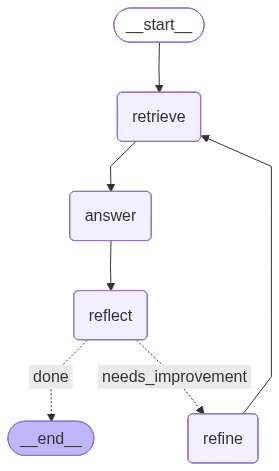

In [27]:
builder = StateGraph(IterativeRAGState)

builder.add_node("retrieve", retrieve_docs)
builder.add_node("answer", generate_answer)
builder.add_node("reflect", reflect_on_answer)
builder.add_node("refine", refine_query)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "answer")
builder.add_edge("answer", "reflect")
builder.add_conditional_edges("reflect", reflection_decision, {"done": END, "needs_improvement": "refine"})
builder.add_edge("refine", "retrieve")
builder.add_edge("answer", END)

graph = builder.compile()
graph

In [28]:
query = "agent loops  and transformer-based systems?"

initial_state = IterativeRAGState(question=query, max_attempt=2)
final = graph.invoke(initial_state)

print("✅ Final Answer:\n")
display(Markdown(final["answer"]))
print("\n🧠 Verified:", final["verified"])
print("🔁 Attempts:", final["attempts"])


✅ Final Answer:



The context provided discusses various aspects of transformer-based systems but does not explicitly mention "agent loops." However, I can offer some insights into how an agent loop might be conceptualized in the context of transformer-based systems.

In general, an "agent loop" refers to the repetitive cycle of perception, decision-making, and action in an autonomous system or agent. When combined with transformer-based systems, this could involve:

1. **Perception:** Utilizing transformer models like Vision Transformers (ViT), Swin Transformer for visual tasks, or Wav2Vec 2.0 for audio tasks to perceive and process input data.

2. **Decision-Making:** Using models like LLaMA2, which are integrated with instruction-tuned layers and knowledge graphs, to reason and decide on a course of action based on structured and unstructured data input.

3. **Action:** Deploying TinyBERT for specific tasks, such as classification in an email triage system, or using deployment architectures that prioritize efficiency and stability, like Reformer models.

In the context of deployment and optimization:
- **Response Alignment and Adapters** could ensure the system's decisions are aligned with expected outcomes while being adaptable to different domains.
- **Mixed-precision training and Memory Efficiency Techniques** (LSH attention, Rotary Positional Encoding, FlashAttention) would enhance the system's performance and resource usage during the loop's processing steps.
- **Canary Rollout and CI/CD Pipelines** ensure that updates are seamlessly integrated, maintaining system performance and reliability.

Hence, an agent loop in transformer-based systems would involve these intricate processes, achieving a balance between model efficiency, task accuracy, and operational integration in practical applications.


🧠 Verified: True
🔁 Attempts: 2
